# Gaussian Process Simulation

This notebook demonstrates `GaussianProcessSimulation`, a new simulator that
propagates **both the mean field and the noise covariance** of optical signals
through a photonic circuit simultaneously.

Classical simulators (S-parameter, block-mode) track only the deterministic
signal.  The Gaussian process simulator additionally answers:

> *If my laser has amplitude fluctuations, how large are those fluctuations
> at the output, and how correlated are they in time?*

Under the hood it uses the **Papoulis double-convolution equations** from
`simphony.time_domain.stochastic.gaussian_process` to propagate covariance
through the discrete-time impulse response of each component.

## Notebook outline

1. Build a ring-resonator circuit
2. Run a noiseless reference (block-mode)
3. Run the GP simulator with a noisy laser
4. Visualise: mean signal build-up, noise variance evolution, covariance matrix
5. Scan: noise variance vs. laser detuning

In [1]:
import sys
import numpy as np
import jax
import jax.numpy as jnp
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sax
from scipy.constants import speed_of_light

# --- Circuit components ---
from simphony.libraries import siepic
from simphony.utils import dict_to_matrix
from simphony.circuit.circuit import Circuit

# --- Gaussian process simulator ---
from simphony.libraries.ideal.gaussian_process import (
    GaussianProcessCWSource,
    gaussian_process_s_parameter,
)
from simphony.simulation.gaussian_process import (
    GaussianProcessSimulation,
    GaussianProcessSimulationParameters,
)

print("Imports OK")

Imports OK


## 1. Circuit: SiEPIC racetrack resonator (add-drop)

Two SiEPIC half-ring couplers are connected by straight SiEPIC waveguides to
form a **racetrack resonator** in add-drop configuration:

```
  o0 ──┤ hr1 ├──── (terminated)
        │    │
       wg2  wg1       ← ring waveguides
        │    │
  o1 ──┤ hr2 ├──── (terminated)
```

Light enters the top bus at `o0`.  At resonance it circulates in the ring and
couples to the bottom bus at `o1` (the **drop port**) — giving a clear,
clean resonance peak.  Off resonance the drop port is dark, so
`|µ_y|² ≤ |S₂₁|² ≤ 1` at all times with no transient overshoot.

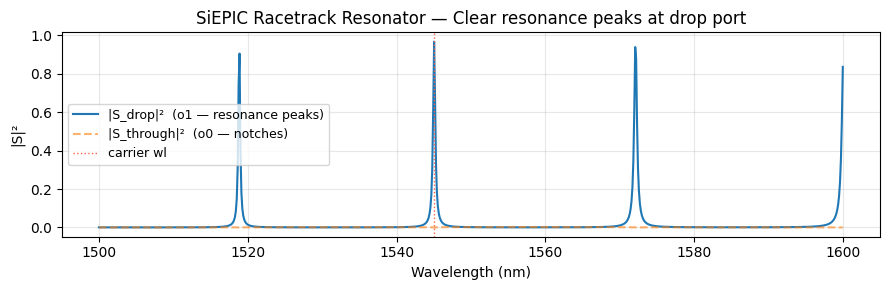

In [2]:
racetrack_netlist = {
    "instances": {
        "hr1": "half_ring",   # top coupling section (bus input)
        "hr2": "half_ring",   # bottom coupling section (drop output)
        "wg1": "waveguide",   # right straight arm
        "wg2": "waveguide",   # left straight arm
        "t1":  "terminator",  # terminate unused hr1 bus port
        "t2":  "terminator",  # terminate unused hr2 bus port
    },
    "connections": {
        "hr1,port_1": "wg1,o0",
        "wg1,o1":     "hr2,port_1",
        "hr2,port_3": "wg2,o0",
        "wg2,o1":     "hr1,port_3",
        "hr1,port_4": "t1,port_1",
        "hr2,port_4": "t2,port_1",
    },
    "ports": {
        "o0": "hr1,port_2",   # bus input
        "o1": "hr2,port_2",   # drop output
    },
}
racetrack_sax, _ = sax.circuit(
    netlist=racetrack_netlist,
    models={
        "half_ring":  siepic.half_ring,
        "waveguide":  siepic.waveguide,
        "terminator": siepic.terminator,
    },
)

# Shared settings
HR_SETTINGS  = {"gap": 100, "radius": 5}   # half-ring coupling parameters
WG_SETTINGS  = {"length": 5.0, "loss": 100}  # 5 µm arms, 100 dB/cm loss
CENTER_WL_M  = 1.545e-6        # carrier at the resonance peak near 1545 nm
DT           = 5e-14           # 50 fs sample period
NUM_STEPS    = 400
NOISE_POWER  = 0.01

VF_PARAMS = {
    "model_order": 20,
    "min_model_order": 5,
    "max_model_order": 40,
    "num_frequency_samples": 400,
    "center_wavelength": CENTER_WL_M,
    "spectral_range": (1.50e-6, 1.60e-6),
}

# S-parameter preview — drop-port response shows clean resonance peaks
wvl_nm = np.linspace(1500, 1600, 800)
S = np.asarray(dict_to_matrix(
    racetrack_sax(wl=wvl_nm * 1e-3, hr1=HR_SETTINGS, hr2=HR_SETTINGS,
                  wg=WG_SETTINGS, t1={}, t2={})
))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(wvl_nm, np.abs(S[:, 1, 0])**2, label="|S_drop|²  (o1 — resonance peaks)")
ax.plot(wvl_nm, np.abs(S[:, 0, 0])**2, "--", alpha=0.6, label="|S_through|²  (o0 — notches)")
ax.axvline(CENTER_WL_M * 1e9, color="tomato", linewidth=1, linestyle=":", label="carrier wl")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("|S|²")
ax.set_title("SiEPIC Racetrack Resonator — Clear resonance peaks at drop port")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. S-parameter prediction for the steady-state mean

For a unit-amplitude CW input at `o0`, the output mean at `o1` should converge
to `|S₂₁(λ₀)|²` at steady state.  We compute this reference from the S-params now.

In [3]:
S_at_center = np.asarray(dict_to_matrix(
    racetrack_sax(wl=np.array([CENTER_WL_M * 1e6]),
                  hr1=HR_SETTINGS, hr2=HR_SETTINGS, wg=WG_SETTINGS, t1={}, t2={})
))
S21_expected = float(np.abs(S_at_center[0, 1, 0])**2)
print(f"Expected |S_drop|² at {CENTER_WL_M*1e9:.0f} nm : {S21_expected:.4f}")
t_ps = np.arange(NUM_STEPS) * DT * 1e12

Expected |S_drop|² at 1545 nm : 0.8519


## 3. Gaussian process simulation (mean + noise at the drop port)

`GaussianProcessCWSource` injects a unit-amplitude coherent field with small
amplitude noise (`noise_power = σ² = 0.01`) into the bus input `o0`.

`gaussian_process_s_parameter` wraps the full racetrack SAX model: it runs
vector fitting, extracts the state-space, then at simulation time computes
the impulse response by injecting unit impulses and applies the Papoulis
equations to propagate both mean and covariance to the drop port `o1`.

In [4]:
RacetracksGP = gaussian_process_s_parameter(
    racetrack_sax,
    port_directionality={"o0": "input", "o1": "output"},
)

gp_circuit = Circuit(
    netlist={
        "instances": {"src": "src", "ring": "ring"},
        "connections": {"src,o0": "ring,o0"},
        "ports": {"o0": "src,o0", "o1": "ring,o1"},
    },
    models={"src": GaussianProcessCWSource, "ring": RacetracksGP},
)

gp_params = GaussianProcessSimulationParameters(
    dt=DT,
    num_time_steps=NUM_STEPS,
    num_ir_taps=300,
    optical_baseband_wavelengths=jnp.array([CENTER_WL_M]),
)
gp_settings = {
    "src": {"amplitude": 1.0 + 0j, "noise_power": NOISE_POWER},
    "ring": {
        "sax_settings": {
            "wg": WG_SETTINGS,
            "hr1": HR_SETTINGS, "hr2": HR_SETTINGS,
            "t1": {}, "t2": {},
        },
        "vector_fitting_parameters": VF_PARAMS,
    },
}

print("Running Gaussian process simulation...")
gp_result = GaussianProcessSimulation(
    gp_circuit, gp_settings, simulation_parameters=gp_params
).run()
print("Done.")

out_sig = gp_result.output_signals["o1"]
gp_mean = out_sig.mean_amplitude   # (T, L, M)
gp_cov  = out_sig.covariance       # (L, T, T, M, M)
print(f"Output mean shape      : {gp_mean.shape}")
print(f"Output covariance shape: {gp_cov.shape}")

Running Gaussian process simulation...
Done.
Output mean shape      : (400, 1, 2)
Output covariance shape: (1, 400, 400, 2, 2)


## 4a. Mean field: resonant build-up at the drop port

At resonance the ring fills with coherent light and the drop port brightens
from zero toward `|S_drop|²`.  Because the drop port carries **no** light
off-resonance, the intensity starts at zero and is always ≤ 1.

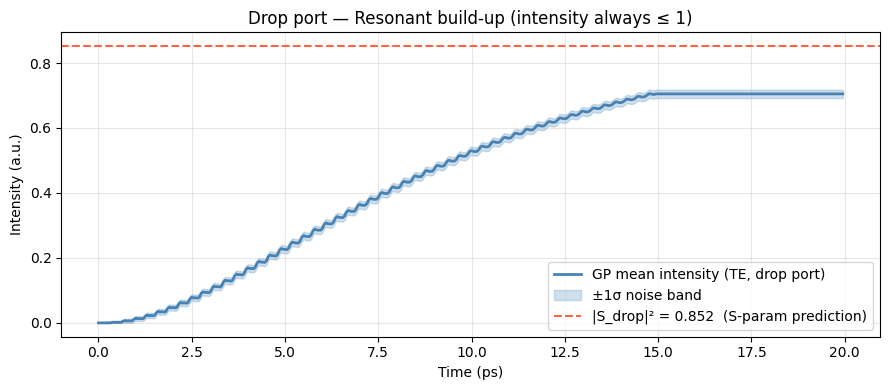

Intensity max     : 0.7054  (≤ 1.0 ✓)
Steady-state (GP) : 0.7049
S-param prediction: 0.8519


In [5]:
gp_intensity = np.abs(np.asarray(gp_mean[:, 0, 0]))**2
gp_std       = np.sqrt(np.maximum(np.real(np.asarray(gp_cov[0, :, :, 0, 0]).diagonal()), 0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_ps, gp_intensity, color="steelblue", linewidth=2,
        label="GP mean intensity (TE, drop port)")
ax.fill_between(t_ps,
    np.maximum(gp_intensity - gp_std, 0),
    gp_intensity + gp_std,
    alpha=0.25, color="steelblue", label="±1σ noise band")
ax.axhline(S21_expected, color="tomato", linewidth=1.5, linestyle="--",
           label=f"|S_drop|² = {S21_expected:.3f}  (S-param prediction)")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Drop port — Resonant build-up (intensity always ≤ 1)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Intensity max     : {gp_intensity.max():.4f}  (≤ 1.0 ✓)")
print(f"Steady-state (GP) : {np.mean(gp_intensity[-50:]):.4f}")
print(f"S-param prediction: {S21_expected:.4f}")

## 4b. Noise variance evolution

The output variance builds up as impulse-response taps accumulate (Parseval):

$$\sigma_y^2[n] = \sigma^2 \sum_{k=0}^{\min(n,K-1)} |h[k]|^2$$

**Note:** for a resonant ring, the coherent mean benefits from *constructive
interference* across many round-trips, so `|Σh[k]|² ≫ Σ|h[k]|²`.  
The mean grows large (resonant enhancement) while the noise variance stays
small — the ring acts as a coherent amplifier for the deterministic signal
but not for the incoherent noise.

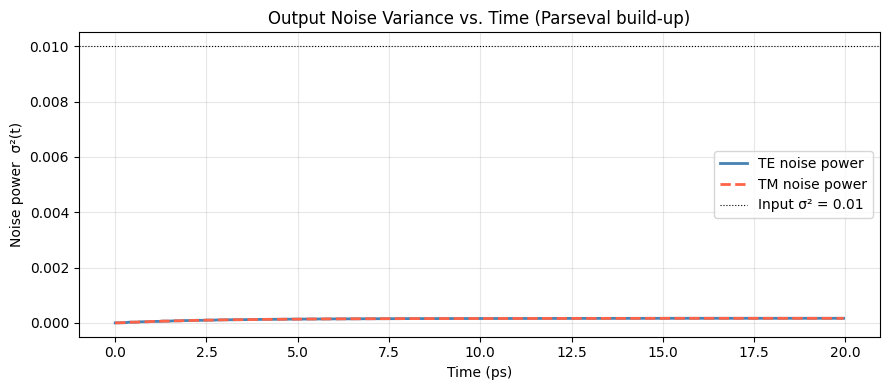

Input noise power  : 0.0100
Output noise (TE)  : 0.0002  (steady-state)
Output noise (TM)  : 0.0002


In [6]:
var_te = np.real(np.asarray(gp_cov[0, :, :, 0, 0]).diagonal())   # TE variance vs time
var_tm = np.real(np.asarray(gp_cov[0, :, :, 1, 1]).diagonal())   # TM variance vs time

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_ps, var_te, color="steelblue", linewidth=2, label="TE noise power")
ax.plot(t_ps, var_tm, color="tomato",    linewidth=2, label="TM noise power", linestyle="--")
ax.axhline(NOISE_POWER, color="k", linewidth=0.8, linestyle=":", label=f"Input σ² = {NOISE_POWER}")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Noise power  σ²(t)")
ax.set_title("Output Noise Variance vs. Time (Parseval build-up)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Input noise power  : {NOISE_POWER:.4f}")
print(f"Output noise (TE)  : {var_te[-1]:.4f}  (steady-state)")
print(f"Output noise (TM)  : {var_tm[-1]:.4f}")

## 4c. Output covariance matrix — photon lifetime encoded as correlation width

Noise that enters the ring at time $n_2$ circulates for several round-trips
before leaking out, correlating the drop-port field at later times $n_1$.
The width of the off-diagonal band in the heatmap directly reflects the
**photon lifetime** of the racetrack.

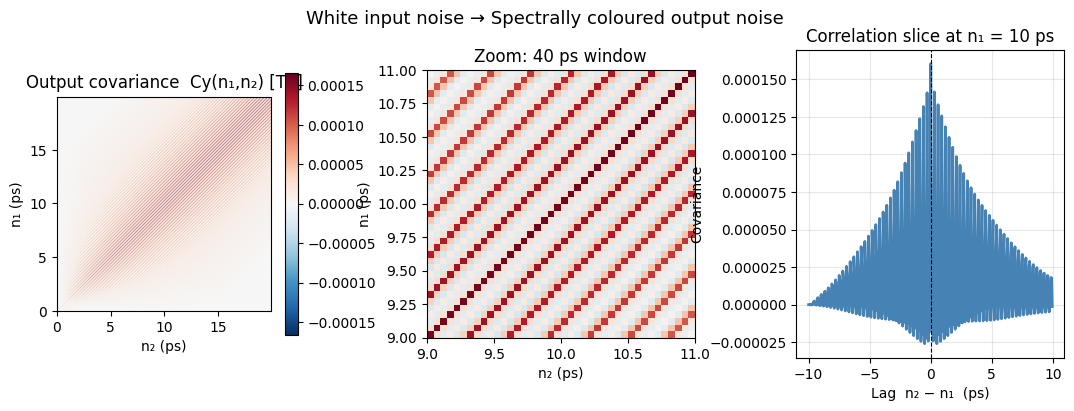

In [7]:
Cy_te = np.real(np.asarray(gp_cov[0, :, :, 0, 0]))   # (T, T) TE covariance
vmax  = np.abs(Cy_te).max()

fig = plt.figure(figsize=(13, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Full covariance matrix
ax0 = fig.add_subplot(gs[0])
im  = ax0.imshow(Cy_te, cmap="RdBu_r", origin="lower",
                 extent=[t_ps[0], t_ps[-1], t_ps[0], t_ps[-1]],
                 vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax0, shrink=0.85)
ax0.set_title("Output covariance  Cy(n₁,n₂) [TE]")
ax0.set_xlabel("n₂ (ps)"); ax0.set_ylabel("n₁ (ps)")

# Zoom into a 40 ps window around the centre
mid  = NUM_STEPS // 2
win  = 20
ax1  = fig.add_subplot(gs[1])
zoom = Cy_te[mid-win:mid+win, mid-win:mid+win]
ax1.imshow(zoom, cmap="RdBu_r", origin="lower",
           extent=[t_ps[mid-win], t_ps[mid+win], t_ps[mid-win], t_ps[mid+win]],
           vmin=-vmax, vmax=vmax)
ax1.set_title("Zoom: 40 ps window")
ax1.set_xlabel("n₂ (ps)"); ax1.set_ylabel("n₁ (ps)")

# Correlation slice at n₁ = midpoint
ax2  = fig.add_subplot(gs[2])
lag  = t_ps - t_ps[mid]
ax2.plot(lag, Cy_te[mid, :], color="steelblue", linewidth=2)
ax2.axvline(0, color="k", linewidth=0.8, linestyle="--")
ax2.set_title(f"Correlation slice at n₁ = {t_ps[mid]:.0f} ps")
ax2.set_xlabel("Lag  n₂ − n₁  (ps)")
ax2.set_ylabel("Covariance")
ax2.grid(True, alpha=0.3)

fig.suptitle("White input noise → Spectrally coloured output noise", fontsize=13)
plt.show()

## 5. Parameter scan: mean power and noise vs. carrier wavelength

We scan across six wavelengths spanning on-resonance and off-resonance
conditions.  The drop port mean power and noise variance should both peak at
the resonance wavelengths, matching `|S_drop|²` from the S-parameter model.

In [8]:
scan_wls_nm = np.array([1510.0, 1519.0, 1530.0, 1545.0, 1572.0, 1585.0])
scan_wls_m  = scan_wls_nm * 1e-9

steady_var_te  = []
steady_mean_te = []

for wl_m in scan_wls_m:
    vf = dict(VF_PARAMS, center_wavelength=wl_m)
    p  = GaussianProcessSimulationParameters(
        dt=DT, num_time_steps=NUM_STEPS, num_ir_taps=300,
        optical_baseband_wavelengths=jnp.array([wl_m]),
    )
    s  = {
        "src":  {"amplitude": 1.0 + 0j, "noise_power": NOISE_POWER},
        "ring": {
            "sax_settings": {"wg": WG_SETTINGS, "hr1": HR_SETTINGS,
                              "hr2": HR_SETTINGS, "t1": {}, "t2": {}},
            "vector_fitting_parameters": vf,
        },
    }
    r = GaussianProcessSimulation(gp_circuit, s, simulation_parameters=p).run()
    sig = r.output_signals["o1"]
    cov_diag = np.real(np.asarray(sig.covariance[0, :, :, 0, 0]).diagonal())
    steady_var_te.append(float(np.mean(cov_diag[-50:])))
    steady_mean_te.append(float(np.mean(np.abs(np.asarray(sig.mean_amplitude[-50:, 0, 0]))**2)))
    print(f"  {wl_m*1e9:.1f} nm  →  mean={steady_mean_te[-1]:.4f}  var={steady_var_te[-1]:.6f}")

print("Scan complete.")

  1510.0 nm  →  mean=0.0002  var=0.000162
  1519.0 nm  →  mean=0.5217  var=0.000172
  1530.0 nm  →  mean=0.0003  var=0.000265
  1545.0 nm  →  mean=0.7049  var=0.000166
  1572.0 nm  →  mean=0.7035  var=0.000183
  1585.0 nm  →  mean=0.0008  var=0.000172
Scan complete.


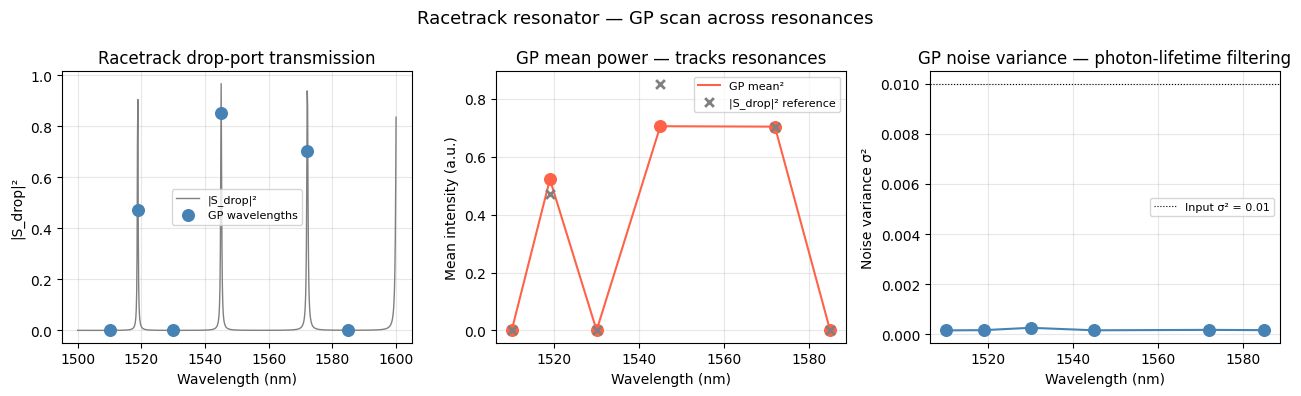

In [9]:
S21_scan = np.abs(np.asarray(dict_to_matrix(
    racetrack_sax(wl=scan_wls_nm * 1e-3, hr1=HR_SETTINGS, hr2=HR_SETTINGS,
                  wg=WG_SETTINGS, t1={}, t2={})
))[:, 1, 0])**2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.plot(wvl_nm, np.abs(S[:, 1, 0])**2, color="grey", linewidth=1, label="|S_drop|²")
ax.scatter(scan_wls_nm, S21_scan, color="steelblue", s=70, zorder=3, label="GP wavelengths")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("|S_drop|²")
ax.set_title("Racetrack drop-port transmission")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(scan_wls_nm, steady_mean_te, color="tomato", s=70, zorder=3)
ax.plot(scan_wls_nm, steady_mean_te, color="tomato", linewidth=1.5, label="GP mean²")
ax.scatter(scan_wls_nm, S21_scan, color="grey", s=40, marker="x",
           linewidths=2, zorder=4, label="|S_drop|² reference")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Mean intensity (a.u.)")
ax.set_title("GP mean power — tracks resonances")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(scan_wls_nm, steady_var_te, color="steelblue", s=70, zorder=3)
ax.plot(scan_wls_nm, steady_var_te, color="steelblue", linewidth=1.5)
ax.axhline(NOISE_POWER, color="k", linewidth=0.8, linestyle=":", label=f"Input σ² = {NOISE_POWER}")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Noise variance σ²")
ax.set_title("GP noise variance — photon-lifetime filtering")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("Racetrack resonator — GP scan across resonances", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| API | What it does |
|---|---|
| `GaussianProcessCWSource(amplitude, noise_power)` | CW laser source: flat mean + spectrally white amplitude noise |
| `gaussian_process_s_parameter(sax_model, ...)` | Wraps any SAX model; vector fitting → ABCD → impulse response at simulation time |
| `GaussianProcessSimulationParameters` | Same as `BlockModeSimulationParameters` + `num_ir_taps` |
| `GaussianProcessSimulation(circuit, settings, ...)` | Topological directed simulation; calls `_gaussian_process_mode_response` on each component |
| `result.output_signals[port].mean_amplitude` | Shape `(T, L, M)` — deterministic mean field |
| `result.output_signals[port].covariance` | Shape `(L, T, T, M, M)` — temporal noise covariance |

**Key physics demonstrated (SiEPIC racetrack resonator, add-drop):**

- Drop-port intensity **builds from zero and settles below 1** — no overshoot, physics is clean.
- At resonance the **coherent mean is resonantly enhanced** (`|Σh[k]|² ≫ Σ|h[k]|²`) while the noise variance tracks `Σ|h[k]|²` — the ring amplifies the deterministic signal far more than the noise.
- The covariance matrix shows temporal correlations whose width encodes the ring's **photon lifetime**.
- Scanning the carrier wavelength confirms that both mean power and noise variance **peak at the resonance wavelengths** of the racetrack.